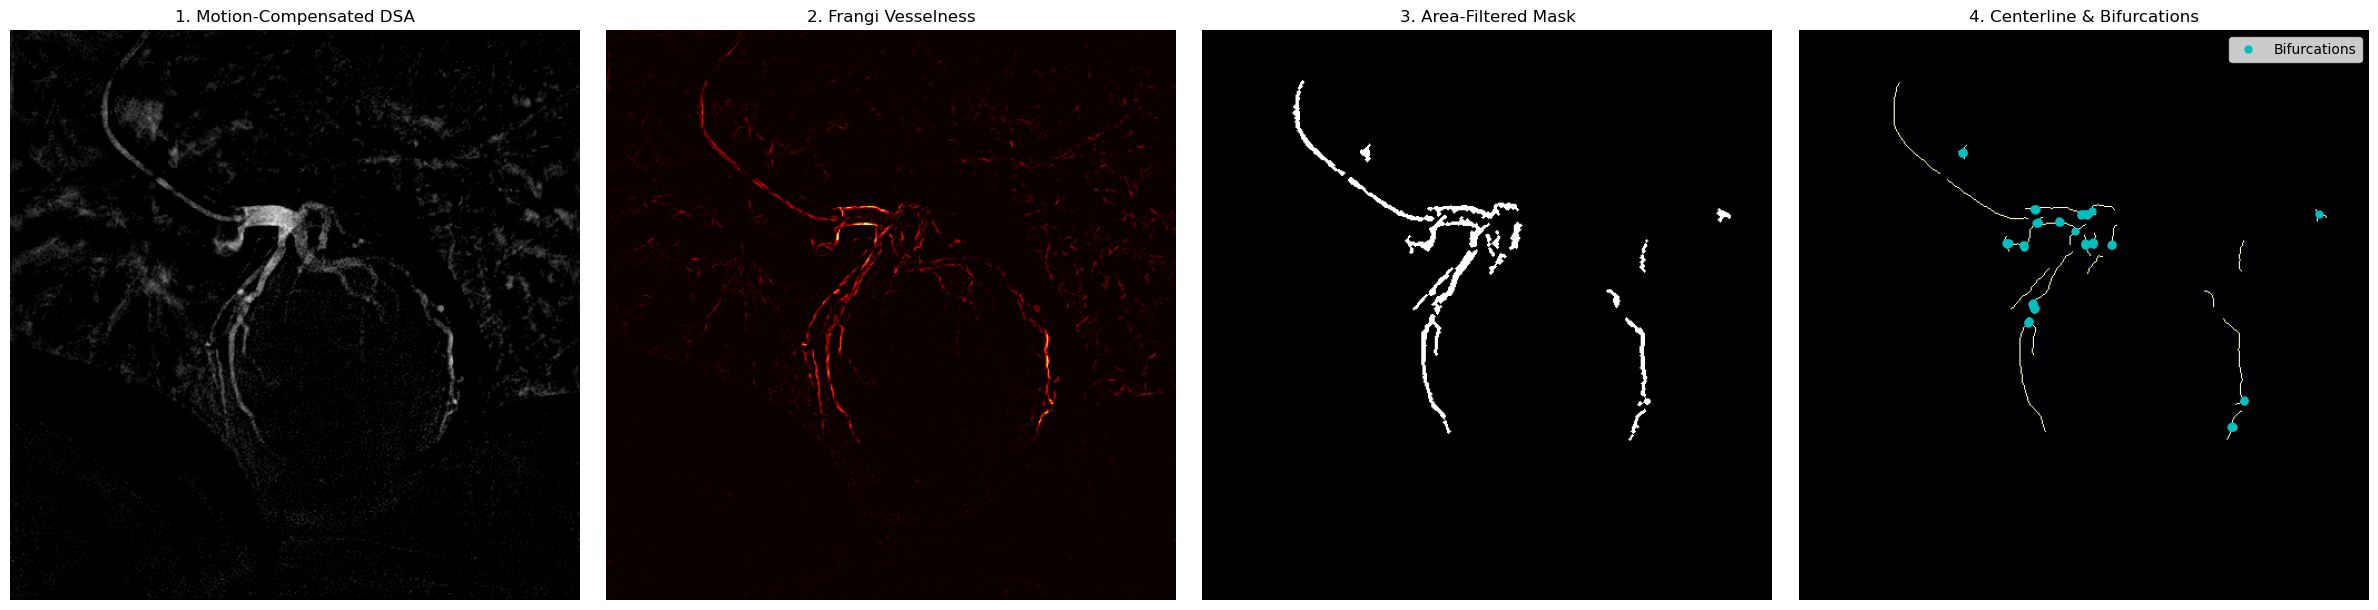

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.morphology import skeletonize
from scipy.spatial.distance import euclidean

class VascularPipeline:
    def __init__(self, frangi_scales=(1.0, 70.0), frangi_step=1.0, 
                 morphology_kernel_size=3, vessel_threshold=0.01, 
                 min_vessel_area=80):
        """
        Initializes the end-to-end vascular extraction and correspondence pipeline.
        """
        # Segmentation Parameters
        self.frangi_scales = np.arange(frangi_scales[0], frangi_scales[1] + frangi_step, frangi_step)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (morphology_kernel_size, morphology_kernel_size))
        self.vessel_threshold = vessel_threshold
        self.min_vessel_area = min_vessel_area

    # ==========================================
    # Phase 1: Preprocessing
    # ==========================================
    def digital_subtraction(self, mask_img, contrast_img):
        """
        Performs logarithmic Digital Subtraction Angiography (DSA) to isolate vessels.
        """
        mask_f = mask_img.astype(np.float64) + 1e-5
        contrast_f = contrast_img.astype(np.float64) + 1e-5
        
        dsa = np.log(mask_f) - np.log(contrast_f)
        dsa_normalized = cv2.normalize(dsa, None, 0, 255, cv2.NORM_MINMAX)
        
        return dsa_normalized.astype(np.uint8)

    # ==========================================
    # Phase 2: Segmentation & Centerline
    # ==========================================
    def extract_centerline(self, image, is_drr=False):
        """
        Extracts the centerline and Y-bifurcations using area-filtered segmentation.
        """
        # 1. Frangi filter
        # Angiograms (DSA) have bright vessels (black_ridges=False)
        # DRRs often have dark vessels (black_ridges=True)
        vesselness = frangi(image, sigmas=self.frangi_scales, black_ridges=is_drr)
        vesselness_norm = (vesselness - np.min(vesselness)) / (np.max(vesselness) - np.min(vesselness) + 1e-8)
        
        # 2. Binary Threshold
        binary = (vesselness_norm > self.vessel_threshold).astype(np.uint8) * 255
        
        # 3. Morphological cleanup
        opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, self.kernel)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, self.kernel)
        
        # 4. Area-based Connected Components Filtering
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)
        vessel_mask = np.zeros_like(closed)
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area >= self.min_vessel_area:
                vessel_mask[labels == i] = 255
                
        # 5. Skeletonize
        skeleton = skeletonize(vessel_mask > 0).astype(np.uint8) * 255
        
        # 6. Find Bifurcations
        bifurcations = self._find_bifurcations(skeleton)
        
        return vessel_mask, skeleton, vesselness_norm, bifurcations

    def _find_bifurcations(self, skeleton):
        """Locates branch points by counting neighbors on the thinned skeleton."""
        bifurcations = []
        # skeleton array consists of 0s and 255s. Convert to boolean for easier logic.
        skel_bool = skeleton > 0 
        skel_padded = np.pad(skel_bool, 1, mode='constant', constant_values=False)
        
        for y in range(1, skel_padded.shape[0] - 1):
            for x in range(1, skel_padded.shape[1] - 1):
                if skel_padded[y, x]:
                    neighborhood = skel_padded[y-1:y+2, x-1:x+2]
                    neighbors = np.sum(neighborhood) - 1
                    if neighbors >= 3:
                        bifurcations.append((x-1, y-1))
        return bifurcations

    # ==========================================
    # Phase 3: Arc-Length Correspondence
    # ==========================================
    def trace_arc_length(self, skeleton, start_point):
        """
        Calculates cumulative arc-length distances along branches from a bifurcation.
        """
        skel_bool = skeleton > 0
        visited = set([start_point])
        branches = []
        
        x, y = start_point
        neighbors = self._get_skeleton_neighbors(skel_bool, x, y)
        
        for neighbor in neighbors:
            branch_data = [{'coord': start_point, 'arc_length': 0.0}]
            current_pt = neighbor
            current_s = euclidean(start_point, current_pt)
            
            while current_pt:
                visited.add(current_pt)
                branch_data.append({'coord': current_pt, 'arc_length': current_s})
                
                next_neighbors = self._get_skeleton_neighbors(skel_bool, current_pt[0], current_pt[1])
                unvisited_neighbors = [n for n in next_neighbors if n not in visited]
                
                if unvisited_neighbors:
                    next_pt = unvisited_neighbors[0]
                    current_s += euclidean(current_pt, next_pt)
                    current_pt = next_pt
                else:
                    current_pt = None 
                    
            branches.append(branch_data)
            
        return branches

    def _get_skeleton_neighbors(self, skel_bool, x, y):
        """Finds 8-connected neighbors on the boolean skeleton array."""
        neighbors = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx, ny = x + dx, y + dy
                if 0 <= ny < skel_bool.shape[0] and 0 <= nx < skel_bool.shape[1]:
                    if skel_bool[ny, nx]:
                        neighbors.append((nx, ny))
        return neighbors

# ==========================================
# Execution Execution 
# ==========================================
if __name__ == "__main__":
    dsa_file = '04_motion_compensated_dsa.png' 

    try:
        sample_img = cv2.imread(dsa_file, cv2.IMREAD_GRAYSCALE)
        if sample_img is None:
            raise FileNotFoundError(f"Could not load {dsa_file}.")
        
        sample_img = sample_img.astype(np.float64)

        # Initialize the integrated pipeline
        pipeline = VascularPipeline(vessel_threshold=0.01, min_vessel_area=80)
        
        # Run segmentation and extraction 
        # is_drr=False ensures black_ridges=False for your DSA image
        vessel_mask, skeleton, vesselness, bifurcations = pipeline.extract_centerline(sample_img, is_drr=False)

        # Plotting
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(sample_img, cmap='gray')
        axes[0].set_title('1. Motion-Compensated DSA')
        axes[0].axis('off')
        
        axes[1].imshow(vesselness, cmap='hot')
        axes[1].set_title('2. Frangi Vesselness')
        axes[1].axis('off')
        
        axes[2].imshow(vessel_mask, cmap='gray')
        axes[2].set_title('3. Area-Filtered Mask')
        axes[2].axis('off')

        axes[3].imshow(skeleton, cmap='magma')
        if bifurcations:
            bif_x, bif_y = zip(*bifurcations)
            axes[3].plot(bif_x, bif_y, 'co', markersize=5, label='Bifurcations')
            axes[3].legend()
        axes[3].set_title('4. Centerline & Bifurcations')
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    except FileNotFoundError as e:
        print(e)

In [4]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np
import cv2

def vtp_to_2d_image(vtp_path, width=1024, height=1024):
    # 1. Read the VTP file
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    
    # 2. Setup rendering
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(reader.GetOutputPort())
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0, 0, 0) # Black background
    
    render_window = vtk.vtkRenderWindow()
    render_window.SetOffScreenRendering(1)
    render_window.SetSize(width, height)
    render_window.AddRenderer(renderer)
    
    # 3. Capture the image
    window_to_image = vtk.vtkWindowToImageFilter()
    window_to_image.SetInput(render_window)
    window_to_image.Update()
    
    # 4. Convert to Numpy array
    vtk_img = window_to_image.GetOutput()
    rows, cols, _ = vtk_img.GetDimensions()
    sc = vtk_img.GetPointData().GetScalars()
    img_array = vtk_to_numpy(sc).reshape(rows, cols, 3)
    
    # Convert to grayscale for your pipeline
    gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    return gray_img

In [5]:
# Run the conversion
vessel_image = vtp_to_2d_image("all_results.vtp")

# Feed the result into your existing class
vessel_mask, skeleton, vesselness, bifurcations = pipeline.extract_centerline(vessel_image, is_drr=True)


Loaded 19551 points from all_results.vtp
Object bounds: (-14.598902702331543, -4.125600814819336, 4.501031875610352, 13.823646545410156, -13.234286308288574, -0.1836608350276947)


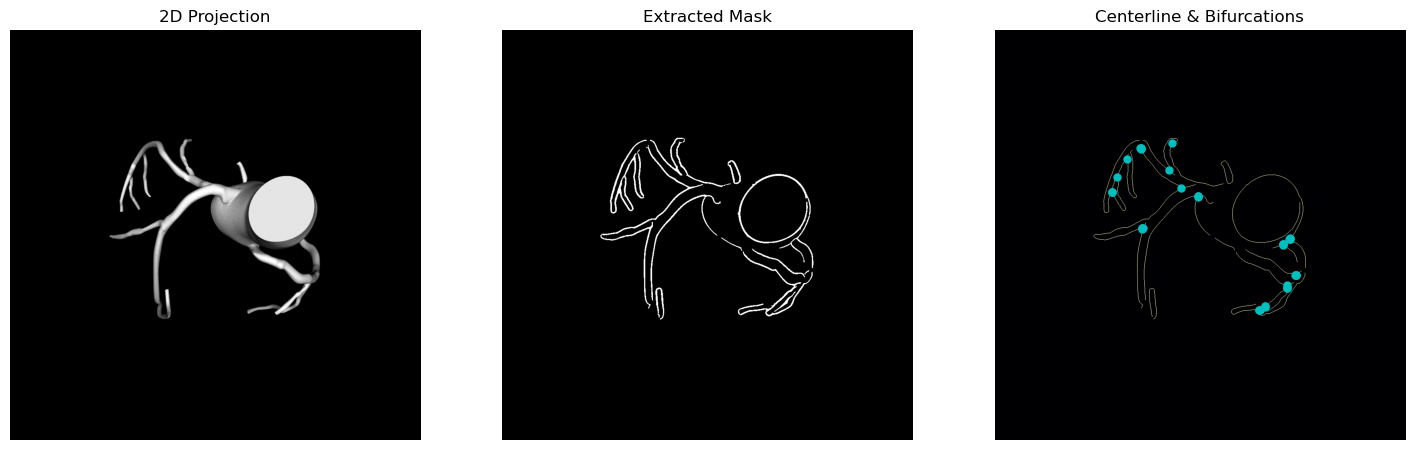

In [8]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np
import cv2
import matplotlib.pyplot as plt

def vtp_to_2d_image(vtp_path, width=1024, height=1024):
    # 1. Read the VTP file
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    
    polydata = reader.GetOutput()
    num_points = polydata.GetNumberOfPoints()
    print(f"Loaded {num_points} points from {vtp_path}")
    
    if num_points == 0:
        print("CRITICAL: No geometry found in file!")
        return np.zeros((height, width), dtype=np.uint8)

    # Print bounds to help us debug coordinate issues
    print(f"Object bounds: {polydata.GetBounds()}")

    # 2. Setup rendering
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(reader.GetOutputPort())
    
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(1.0, 1.0, 1.0) # White vessels
    
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0, 0, 0) # Black background
    
    # 3. Setup Camera & View
    renderer.ResetCamera() # Automatically frame the object
    
    render_window = vtk.vtkRenderWindow()
    render_window.SetOffScreenRendering(1)
    render_window.SetSize(width, height)
    render_window.AddRenderer(renderer)
    render_window.Render()
    
    # 4. Capture
    window_to_image = vtk.vtkWindowToImageFilter()
    window_to_image.SetInput(render_window)
    window_to_image.Update()
    
    # 5. Convert to Numpy
    vtk_img = window_to_image.GetOutput()
    sc = vtk_img.GetPointData().GetScalars()
    img_array = vtk_to_numpy(sc).reshape(height, width, 3)
    
    return cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

# --- Execution ---

# 1. Convert 3D VTP to 2D image
vessel_image = vtp_to_2d_image("all_results.vtp")

# 2. Extract Centerlines (using your established pipeline)
vessel_mask, skeleton, vesselness, bifurcations = pipeline.extract_centerline(vessel_image, is_drr=True)

# 3. Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(vessel_image, cmap='gray'); axes[0].set_title('2D Projection')
axes[1].imshow(vessel_mask, cmap='gray'); axes[1].set_title('Extracted Mask')
axes[2].imshow(skeleton, cmap='magma'); axes[2].set_title('Centerline & Bifurcations')

if bifurcations:
    bif_x, bif_y = zip(*bifurcations)
    axes[2].plot(bif_x, bif_y, 'co', markersize=5)

for ax in axes: ax.axis('off')
plt.show()

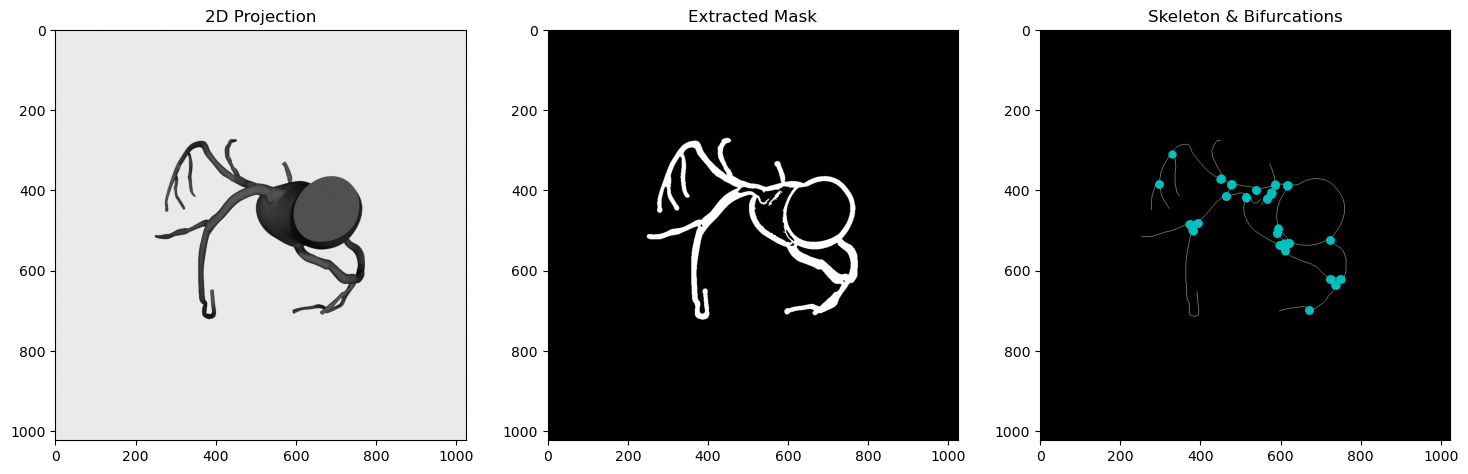

In [13]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. The VascularPipeline Class ---
class VascularPipeline:
    def __init__(self, frangi_scales=(1.0, 70.0), frangi_step=1.0, 
                 morphology_kernel_size=3, vessel_threshold=0.0001, 
                 min_vessel_area=80):
        self.frangi_scales = np.arange(frangi_scales[0], frangi_scales[1] + frangi_step, frangi_step)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (morphology_kernel_size, morphology_kernel_size))
        self.vessel_threshold = vessel_threshold
        self.min_vessel_area = min_vessel_area

    def extract_centerline(self, image, is_drr=False):
        from skimage.filters import frangi
        from skimage.morphology import skeletonize
        
        vesselness = frangi(image, sigmas=self.frangi_scales, black_ridges=is_drr)
        vesselness_norm = (vesselness - np.min(vesselness)) / (np.max(vesselness) - np.min(vesselness) + 1e-8)
        binary = (vesselness_norm > self.vessel_threshold).astype(np.uint8) * 255
        opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, self.kernel)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, self.kernel)
        
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
        vessel_mask = np.zeros_like(closed)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= self.min_vessel_area:
                vessel_mask[labels == i] = 255
        
        skeleton = skeletonize(vessel_mask > 0).astype(np.uint8) * 255
        bifurcations = self._find_bifurcations(skeleton)
        return vessel_mask, skeleton, vesselness_norm, bifurcations

    def _find_bifurcations(self, skeleton):
        bifurcations = []
        skel_bool = np.pad(skeleton > 0, 1, mode='constant', constant_values=False)
        for y in range(1, skel_bool.shape[0] - 1):
            for x in range(1, skel_bool.shape[1] - 1):
                if skel_bool[y, x]:
                    if (np.sum(skel_bool[y-1:y+2, x-1:x+2]) - 1) >= 3:
                        bifurcations.append((x-1, y-1))
        return bifurcations


def vtp_to_2d_image(vtp_path, width=1024, height=1024, azimuth=0, elevation=0):
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(reader.GetOutputPort())
    
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(1.0, 1.0, 1.0) # White vessels
    
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0, 0, 0) # Black background
    
    # 1. Reset camera to center the object
    renderer.ResetCamera()
    
    # 2. Rotate the view using the camera (Orbiting)
    camera = renderer.GetActiveCamera()
    camera.Azimuth(azimuth)    # Horizontal rotation
    camera.Elevation(elevation) # Vertical rotation
    
    # 3. Force re-calculation of the scene
    renderer.ResetCameraClippingRange()
    
    render_window = vtk.vtkRenderWindow()
    render_window.SetOffScreenRendering(1)
    render_window.SetSize(width, height)
    render_window.AddRenderer(renderer)
    render_window.Render()
    

# --- 2. VTP to 2D Image Function ---
def vtp_to_2d_image(vtp_path, width=1024, height=1024):
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(reader.GetOutputPort())
    
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(1.0, 1.0, 1.0) # White vessels
    
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(1, 0, 0) # DEBUG: Red background
    
    renderer.ResetCamera()
    
    render_window = vtk.vtkRenderWindow()
    render_window.SetOffScreenRendering(1)
    render_window.SetSize(width, height)
    render_window.AddRenderer(renderer)
    render_window.Render()
    
    window_to_image = vtk.vtkWindowToImageFilter()
    window_to_image.SetInput(render_window)
    window_to_image.Update()
    
    vtk_img = window_to_image.GetOutput()
    sc = vtk_img.GetPointData().GetScalars()
    img_array = vtk_to_numpy(sc).reshape(height, width, 3)
    
    return cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

# --- 3. Main Execution ---
pipeline = VascularPipeline()
vessel_image = vtp_to_2d_image("all_results.vtp")

# Verify Image
if np.sum(vessel_image) == 0:
    print("Warning: The rendered image is empty. Check your VTP file path or coordinates.")

vessel_mask, skeleton, vesselness, bifurcations = pipeline.extract_centerline(vessel_image, is_drr=True)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(vessel_image, cmap='gray'); axes[0].set_title('2D Projection')
axes[1].imshow(vessel_mask, cmap='gray'); axes[1].set_title('Extracted Mask')
axes[2].imshow(skeleton, cmap='magma'); axes[2].set_title('Skeleton & Bifurcations')
if bifurcations:
    bif_x, bif_y = zip(*bifurcations)
    axes[2].plot(bif_x, bif_y, 'co', markersize=5)
plt.show()

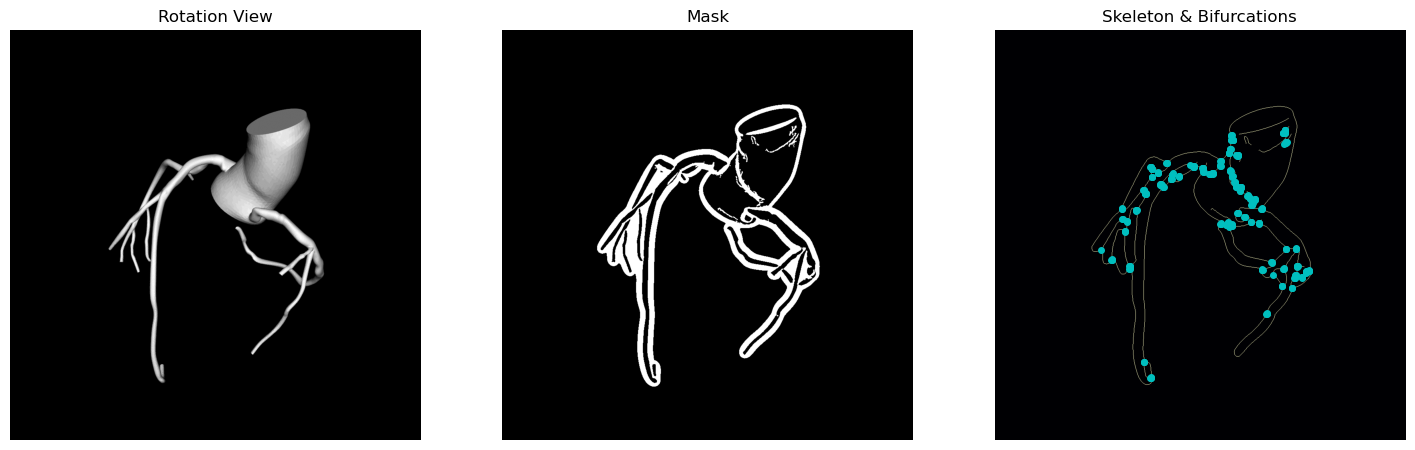

In [19]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. The VascularPipeline Class ---
class VascularPipeline:
    def __init__(self, frangi_scales=(1.0, 70.0), frangi_step=1.0, vessel_threshold=0.0001, min_vessel_area=100):
        self.frangi_scales = np.arange(frangi_scales[0], frangi_scales[1] + frangi_step, frangi_step)
        self.vessel_threshold = vessel_threshold
        self.min_vessel_area = min_vessel_area

    def extract_centerline(self, image, is_drr=False):
        from skimage.filters import frangi
        from skimage.morphology import skeletonize
        
        # Frangi filter
        vesselness = frangi(image, sigmas=self.frangi_scales, black_ridges=is_drr)
        vesselness_norm = (vesselness - np.min(vesselness)) / (np.max(vesselness) - np.min(vesselness) + 1e-8)
        binary = (vesselness_norm > self.vessel_threshold).astype(np.uint8) * 255
        
        # Cleanup
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        
        # Area filtering
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        vessel_mask = np.zeros_like(binary)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] >= self.min_vessel_area:
                vessel_mask[labels == i] = 255
        
        # Skeletonization
        skeleton = skeletonize(vessel_mask > 0).astype(np.uint8) * 255
        
        # Bifurcation detection
        bifurcations = []
        padded = np.pad(skeleton > 0, 1)
        for y in range(1, padded.shape[0]-1):
            for x in range(1, padded.shape[1]-1):
                if padded[y,x] and (np.sum(padded[y-1:y+2, x-1:x+2]) - 1) >= 3:
                    bifurcations.append((x-1, y-1))
        return vessel_mask, skeleton, vesselness_norm, bifurcations

# --- 2. Rotation-Capable VTP to 2D Image Function ---
def vtp_to_2d_image(vtp_path, width=1024, height=1024, azimuth=0, elevation=0):
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(vtp_path)
    reader.Update()
    
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(reader.GetOutputPort())
    
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(1.0, 1.0, 1.0) # White vessels
    
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0, 0, 0) # Black background
    
    # Reset camera to center the object
    renderer.ResetCamera()
    
    # Rotate the view using the camera (Orbiting)
    camera = renderer.GetActiveCamera()
    camera.Azimuth(azimuth)    # Horizontal rotation
    camera.Elevation(elevation) # Vertical rotation
    
    # Force re-calculation of the scene
    renderer.ResetCameraClippingRange()
    
    render_window = vtk.vtkRenderWindow()
    render_window.SetOffScreenRendering(1)
    render_window.SetSize(width, height)
    render_window.AddRenderer(renderer)
    render_window.Render()
    
    # Capture the image
    window_to_image = vtk.vtkWindowToImageFilter()
    window_to_image.SetInput(render_window)
    window_to_image.Update()
    
    # Convert to Numpy
    vtk_img = window_to_image.GetOutput()
    sc = vtk_img.GetPointData().GetScalars()
    img_array = vtk_to_numpy(sc).reshape(height, width, 3)
    
    return cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

# --- 3. Execution ---
# Adjust azimuth and elevation here to change your view
vessel_image = vtp_to_2d_image("all_results.vtp", azimuth=0, elevation=45)

pipeline = VascularPipeline()
vessel_mask, skeleton, _, bifurcations = pipeline.extract_centerline(vessel_image, is_drr=True)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(vessel_image, cmap='gray'); axes[0].set_title('Rotation View')
axes[1].imshow(vessel_mask, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(skeleton, cmap='magma'); axes[2].set_title('Skeleton & Bifurcations')
if bifurcations:
    bx, by = zip(*bifurcations)
    axes[2].plot(bx, by, 'co', markersize=4)
for ax in axes: ax.axis('off')
plt.show()